# Morphological & Spatial Distribution Feature Extraction

Notebook này trích xuất đặc trưng từ **hình thái học đa thang đo** và **phân bố không gian** của các vùng mask – hai hướng không có trong notebook 02.

Hai phương pháp chính:
1. **Morphological Profile (Erosion/Dilation)**: Mô phỏng "độ dày" của mask ở nhiều bán kính → phân biệt blob đặc/rỗng, ngưng kết dày/mỏng.
2. **Spatial Distribution Features**: Bao gồm Hu Moments (bất biến với tỷ lệ/góc quay), phân bố bán kính, và trọng tâm tương đối → nắm bắt vị trí và hình dạng vùng phản ứng trong ảnh.

**Output:** `processed/morphological_spatial/morphological_spatial_features.csv`


## 0. Setup & Imports

In [1]:
from pathlib import Path
import json, re, math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SPLITS = ["train", "valid", "test"]

if IN_COLAB:
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/Blood Group Detection.coco")
else:
    ROOT = Path.cwd()

if not all((ROOT / s / "_annotations.coco.json").exists() for s in SPLITS):
    raise FileNotFoundError("COCO dataset not found. Edit ROOT.")

OUTPUT_DIR = ROOT / "processed" / "morphological_spatial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Morphological radii (pixel)
MORPH_RADII     = [2, 4, 8, 16]
# Radial distribution bins
RADIAL_BINS     = 10
# Angular distribution bins (sector histogram)
ANGULAR_BINS    = 8

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
ROOT, OUTPUT_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(PosixPath('/content/drive/MyDrive/Blood Group Detection.coco'),
 PosixPath('/content/drive/MyDrive/Blood Group Detection.coco/processed/morphological_spatial'))

## 1. Load Image List

In [2]:
def parse_blood_group(name):
    m = re.match(r"^(AB|A|B|O)[+-]", name)
    return m.group(0) if m else "UNKNOWN"

def load_images_table():
    rows = []
    for split in SPLITS:
        path = ROOT / split / "_annotations.coco.json"
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        for img in data["images"]:
            orig = img.get("extra", {}).get("name", img["file_name"])
            bg   = parse_blood_group(orig)
            rows.append({
                "split": split, "image_id": img["id"],
                "file_name": img["file_name"], "original_name": orig,
                "blood_group": bg,
                "abo": bg[:-1] if bg != "UNKNOWN" else "UNKNOWN",
                "rh":  bg[-1]  if bg != "UNKNOWN" else "UNKNOWN",
                "width": img["width"], "height": img["height"],
                "image_path": str(ROOT / split / img["file_name"]),
            })
    return pd.DataFrame(rows)

images_df = load_images_table()
print(f"Loaded {len(images_df)} images")
images_df.head()

Loaded 2072 images


,split,image_id,file_name,original_name,blood_group,abo,rh,width,height,image_path
0,train,0,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B- (8).jpg,B-,B,-,2644,868,/content/drive/MyDrive/Blood Group Detection.c...
1,train,1,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB- (59).jpg,AB-,AB,-,991,302,/content/drive/MyDrive/Blood Group Detection.c...
2,train,2,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+ (7).jpg,A+,A,+,1995,607,/content/drive/MyDrive/Blood Group Detection.c...
3,train,3,A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg,A+ (14).jpg,A+,A,+,2538,768,/content/drive/MyDrive/Blood Group Detection.c...
4,train,4,B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg,B- (95).jpg,B-,B,-,1019,341,/content/drive/MyDrive/Blood Group Detection.c...


## 2. Color Segmentation (giống notebook 02)

In [3]:
def read_rgb(path, max_side=1200):
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    scale = max(h, w) / max_side
    if scale > 1:
        rgb = cv2.resize(rgb, (int(w/scale), int(h/scale)), interpolation=cv2.INTER_AREA)
    return rgb

def clean_mask(mask, kernel_size=5, min_area=80):
    mask = mask.astype(np.uint8)
    k = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            out[labels == lbl] = 1
    return out.astype(bool)

def segment_image(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    masks = {
        "anti_a_blue":   clean_mask((h>=80)&(h<=135)&(s>=35)&(v>=35), 5, 120),
        "anti_b_yellow": clean_mask((h>=15)&(h<=45) &(s>=35)&(v>=45), 5, 120),
        "blood_red":     clean_mask(((h<=12)|(h>=165))&(s>=30)&(v>=30), 5, 120),
        "foreground":    clean_mask(((s>=38)&(v>=30)&(v<=250))|((s>=18)&(v<=150)), 5, 200),
    }
    masks["reaction_candidate"] = masks["foreground"] & (
        masks["blood_red"] | masks["anti_a_blue"] | masks["anti_b_yellow"])
    return masks

## 3. Feature Extraction Functions

### 3.1. Morphological Profile Features

Áp dụng erosion và dilation với các kernel hình tròn bán kính R ∈ {2, 4, 8, 16 px}:

- **erode_r{R}_ratio**: Tỷ lệ mask còn lại sau erosion → đo "lõi đặc" của blob.
- **dilate_r{R}_ratio**: Tỷ lệ mask sau dilation → đo "vùng ảnh hưởng".
- **shell_r{R}_ratio**: Vùng giữa dilated và eroded → đo "lớp vỏ" hay viền.
- **thickness_score_r{R}**: Tỷ lệ eroded/original area → blob dày (gần 1.0) hay mỏng (gần 0).
- **fill_ratio_r{R}**: eroded/dilated → blob đặc hay rỗng.

Các feature này nắm bắt cấu trúc không thể thấy qua histogram màu hay LBP.


In [4]:
def morph_profile_features(mask, prefix):
    """Morphological profile ở nhiều bán kính."""
    feats = {}
    orig_area = float(mask.sum()) + 1e-9
    img_area  = float(mask.size)

    for r in MORPH_RADII:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
        eroded  = cv2.erode(mask.astype(np.uint8), kernel).astype(bool)
        dilated = cv2.dilate(mask.astype(np.uint8), kernel).astype(bool)
        shell   = dilated & ~eroded

        erode_area  = float(eroded.sum())
        dilate_area = float(dilated.sum())

        feats[f"{prefix}_erode_r{r}_ratio"]     = erode_area / img_area
        feats[f"{prefix}_dilate_r{r}_ratio"]    = dilate_area / img_area
        feats[f"{prefix}_shell_r{r}_ratio"]     = float(shell.sum()) / img_area
        feats[f"{prefix}_thickness_score_r{r}"] = erode_area / orig_area
        feats[f"{prefix}_fill_ratio_r{r}"]      = erode_area / (dilate_area + 1e-9)

    # Morphological gradient (dilated - eroded at r=2) normalised
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    grad = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_GRADIENT, k2).astype(bool)
    feats[f"{prefix}_morph_gradient_ratio"] = float(grad.sum()) / img_area

    # Morphological open-close difference: roughness indicator
    k_sm = np.ones((3,3), np.uint8)
    opened = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN,  k_sm).astype(bool)
    closed = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, k_sm).astype(bool)
    feats[f"{prefix}_open_close_diff"] = float(np.abs(closed.astype(int) - opened.astype(int)).sum()) / img_area

    return feats

### 3.2. Spatial Distribution Features

Nhóm feature mô tả **vị trí và hình dạng** của mask trong không gian ảnh:

**Hu Moments (7 giá trị)**: bất biến với phép tịnh tiến, xoay và tỷ lệ – mô tả hình dạng tổng thể.

**Trọng tâm tương đối**: vị trí trung tâm khối lượng của mask so với kích thước ảnh.

**Phân bố bán kính (10 bin)**: mật độ pixel mask theo khoảng cách từ trọng tâm → phân biệt blob đặc vs viền.

**Phân bố góc (8 sector)**: mật độ pixel theo góc từ trọng tâm → phát hiện phân bố không đối xứng.

**Bounding box aspect ratio & fill**: đặc tả hình chữ nhật bao.


In [5]:
def spatial_distribution_features(mask, prefix):
    """Hu moments, phân bố bán kính, góc, trọng tâm."""
    feats = {}
    H, W  = mask.shape
    img_area = float(H * W)

    mask_u8 = mask.astype(np.uint8)

    # ── Hu Moments ───────────────────────────────────────────────────────────────
    moments = cv2.moments(mask_u8)
    hu = cv2.HuMoments(moments).flatten()
    for i, val in enumerate(hu):
        # Log-scale: sign(v) * log(|v| + 1e-9)
        feats[f"{prefix}_hu_{i}"] = float(math.copysign(math.log(abs(val) + 1e-9), val))

    # ── Centroid (normalised by image size) ──────────────────────────────────────
    m00 = moments["m00"] + 1e-9
    cx  = moments["m10"] / m00
    cy  = moments["m01"] / m00
    feats[f"{prefix}_centroid_x_norm"] = cx / W
    feats[f"{prefix}_centroid_y_norm"] = cy / H

    # ── Radial & angular distribution ────────────────────────────────────────────
    ys, xs = np.where(mask)
    if ys.size == 0:
        for b in range(RADIAL_BINS):
            feats[f"{prefix}_radial_bin{b}"] = 0.0
        for b in range(ANGULAR_BINS):
            feats[f"{prefix}_angular_bin{b}"] = 0.0
        feats[f"{prefix}_radial_max_bin"] = 0
        feats[f"{prefix}_radial_spread"]  = 0.0
        feats[f"{prefix}_angular_entropy"] = 0.0
    else:
        dx  = xs - cx
        dy  = ys - cy
        r   = np.sqrt(dx**2 + dy**2)
        ang = np.degrees(np.arctan2(dy, dx)) % 360   # 0..360

        # Radial histogram
        r_max = r.max() + 1e-9
        r_bins = np.linspace(0, r_max, RADIAL_BINS + 1)
        r_hist, _ = np.histogram(r, bins=r_bins)
        r_total = r_hist.sum() + 1e-9
        for b, v in enumerate(r_hist):
            feats[f"{prefix}_radial_bin{b}"] = float(v / r_total)
        feats[f"{prefix}_radial_max_bin"] = int(np.argmax(r_hist))
        feats[f"{prefix}_radial_spread"]  = float(r.std())

        # Angular (sector) histogram
        a_bins = np.linspace(0, 360, ANGULAR_BINS + 1)
        a_hist, _ = np.histogram(ang, bins=a_bins)
        a_total = a_hist.sum() + 1e-9
        a_prob  = a_hist / a_total
        for b, v in enumerate(a_prob):
            feats[f"{prefix}_angular_bin{b}"] = float(v)
        # Angular entropy: uniformly distributed → high entropy; concentrated → low
        p = a_prob[a_prob > 0]
        feats[f"{prefix}_angular_entropy"] = float(-(p * np.log2(p)).sum())

    # ── Bounding box features ────────────────────────────────────────────────────
    if ys.size == 0:
        feats[f"{prefix}_bbox_aspect_ratio"]  = 0.0
        feats[f"{prefix}_bbox_fill_ratio"]    = 0.0
        feats[f"{prefix}_bbox_area_norm"]     = 0.0
    else:
        h_box = float(ys.max() - ys.min() + 1)
        w_box = float(xs.max() - xs.min() + 1)
        feats[f"{prefix}_bbox_aspect_ratio"]  = h_box / (w_box + 1e-9)
        feats[f"{prefix}_bbox_fill_ratio"]    = float(mask.sum()) / (h_box * w_box + 1e-9)
        feats[f"{prefix}_bbox_area_norm"]     = (h_box * w_box) / img_area

    return feats

## 4. Tổng hợp feature cho một ảnh

In [6]:
MASK_NAMES = ["anti_a_blue", "anti_b_yellow", "blood_red", "foreground", "reaction_candidate"]

def extract_morphological_spatial_features(rgb):
    masks = segment_image(rgb)
    feats = {"resized_width": rgb.shape[1], "resized_height": rgb.shape[0]}
    for mn in MASK_NAMES:
        mask = masks.get(mn, np.zeros(rgb.shape[:2], dtype=bool))
        feats[f"{mn}_mask_present"] = int(mask.any())
        feats.update(morph_profile_features(mask, mn))
        feats.update(spatial_distribution_features(mask, mn))
    return feats

# Smoke-test
dummy = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)
dummy_feats = extract_morphological_spatial_features(dummy)
print(f"Feature count per image: {len(dummy_feats)}")
print(list(dummy_feats.keys())[:15])

Feature count per image: 282
['resized_width', 'resized_height', 'anti_a_blue_mask_present', 'anti_a_blue_erode_r2_ratio', 'anti_a_blue_dilate_r2_ratio', 'anti_a_blue_shell_r2_ratio', 'anti_a_blue_thickness_score_r2', 'anti_a_blue_fill_ratio_r2', 'anti_a_blue_erode_r4_ratio', 'anti_a_blue_dilate_r4_ratio', 'anti_a_blue_shell_r4_ratio', 'anti_a_blue_thickness_score_r4', 'anti_a_blue_fill_ratio_r4', 'anti_a_blue_erode_r8_ratio', 'anti_a_blue_dilate_r8_ratio']


## 5. Visualization: Morphological Profiles & Spatial Distribution

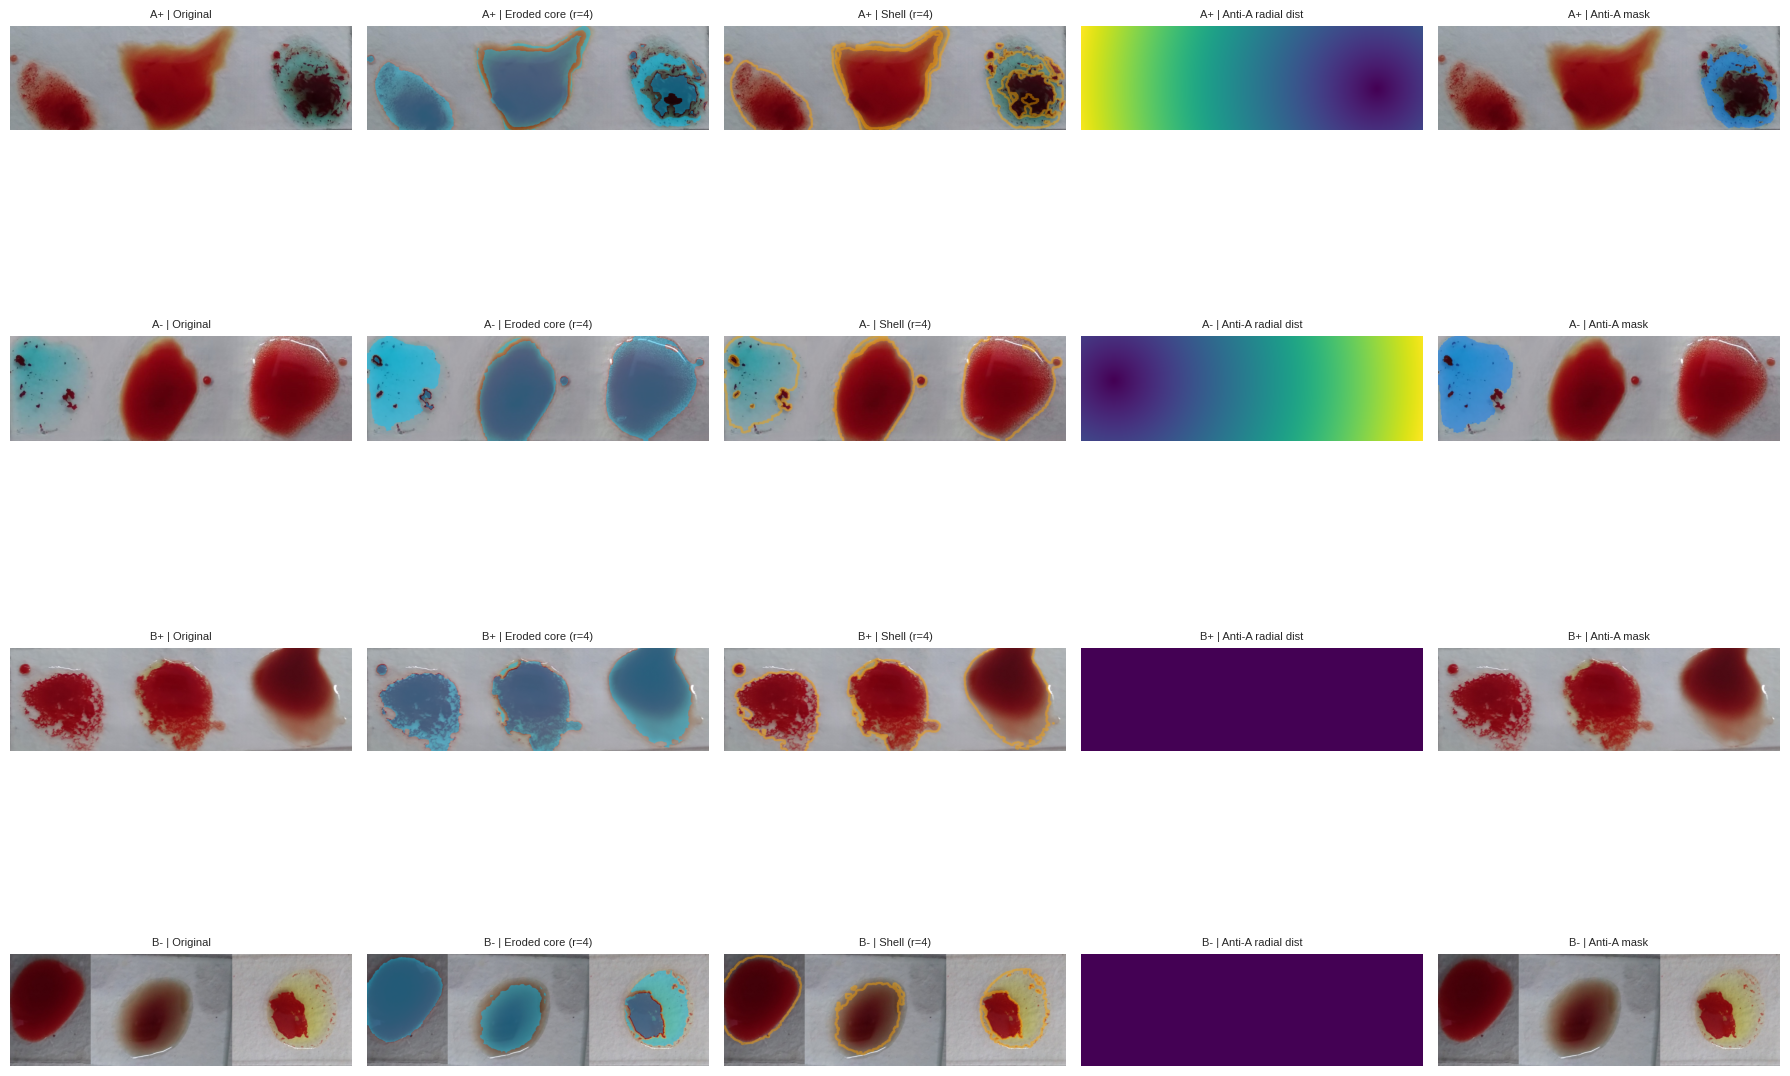

In [7]:
def pick_one_per_group(df):
    order = ["A+","A-","B+","B-","AB+","AB-","O+","O-"]
    return pd.DataFrame([df[df["blood_group"]==lbl].iloc[0]
                         for lbl in order if not df[df["blood_group"]==lbl].empty])

samples = pick_one_per_group(images_df)

def overlay_mask(rgb, mask, color=(255,0,0), alpha=0.45):
    out = rgb.copy().astype(np.float32)
    out[mask] = (1-alpha)*out[mask] + alpha*np.array(color)
    return out.astype(np.uint8)

def visualize_morph_spatial(samples, n=4):
    n = min(n, len(samples))
    fig, axes = plt.subplots(n, 5, figsize=(18, 3.5*n))
    if n == 1: axes = np.array([axes])

    for r, (_, row) in enumerate(samples.head(n).iterrows()):
        rgb   = read_rgb(row["image_path"])
        masks = segment_image(rgb)
        mask  = masks["reaction_candidate"]
        H, W  = mask.shape

        # Erosion at r=4
        k4      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        eroded  = cv2.erode(mask.astype(np.uint8), k4).astype(bool)
        dilated = cv2.dilate(mask.astype(np.uint8), k4).astype(bool)
        shell   = dilated & ~eroded

        # Radial distribution of anti_a_blue mask
        a_mask = masks["anti_a_blue"]
        ys, xs = np.where(a_mask)
        radial_map = np.zeros((H, W), dtype=np.float32)
        if ys.size > 0:
            cx, cy = xs.mean(), ys.mean()
            dy_g, dx_g = np.mgrid[:H, :W]
            radial_map = np.sqrt((dx_g - cx)**2 + (dy_g - cy)**2)

        shell_overlay  = overlay_mask(rgb, shell,  (255, 165, 0))
        erode_overlay  = overlay_mask(rgb, eroded, (0, 200, 255))

        views = [
            (rgb,          "Original",             None),
            (erode_overlay,"Eroded core (r=4)",    None),
            (shell_overlay,"Shell (r=4)",           None),
            (radial_map,   "Anti-A radial dist",   "viridis"),
            (overlay_mask(rgb, a_mask, (0,120,255)), "Anti-A mask", None),
        ]
        for c, (img, ttl, cmap) in enumerate(views):
            axes[r,c].imshow(img, cmap=cmap)
            axes[r,c].set_title(f"{row['blood_group']} | {ttl}", fontsize=8)
            axes[r,c].axis("off")

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR/"morphological_spatial_preview.png"), dpi=100, bbox_inches="tight")
    plt.show()

visualize_morph_spatial(samples)

## 6. Trích feature toàn bộ dataset

In [8]:
rows, errors = [], []
for idx, row in images_df.iterrows():
    try:
        rgb   = read_rgb(row["image_path"])
        feats = extract_morphological_spatial_features(rgb)
        feats.update({k: row[k] for k in ["split","file_name","blood_group","abo","rh"]})
        rows.append(feats)
    except Exception as e:
        errors.append({"file": row["file_name"], "error": str(e)})
    if (idx+1) % 50 == 0:
        print(f"Processed {idx+1}/{len(images_df)}")

print(f"Done: {len(rows)} ok, {len(errors)} errors")
if errors: print("Errors:", errors[:3])

Processed 50/2072
Processed 100/2072
Processed 150/2072
Processed 200/2072
Processed 250/2072
Processed 300/2072
Processed 350/2072
Processed 400/2072
Processed 450/2072
Processed 500/2072
Processed 550/2072
Processed 600/2072
Processed 650/2072
Processed 700/2072
Processed 750/2072
Processed 800/2072
Processed 850/2072
Processed 900/2072
Processed 950/2072
Processed 1000/2072
Processed 1050/2072
Processed 1100/2072
Processed 1150/2072
Processed 1200/2072
Processed 1250/2072
Processed 1300/2072
Processed 1350/2072
Processed 1400/2072
Processed 1450/2072
Processed 1500/2072
Processed 1550/2072
Processed 1600/2072
Processed 1650/2072
Processed 1700/2072
Processed 1750/2072
Processed 1800/2072
Processed 1850/2072
Processed 1900/2072
Processed 1950/2072
Processed 2000/2072
Processed 2050/2072
Done: 2072 ok, 0 errors


In [9]:
morph_df = pd.DataFrame(rows)
meta_cols = ["split","file_name","blood_group","abo","rh","resized_width","resized_height"]
other_cols = [c for c in morph_df.columns if c not in meta_cols]
morph_df = morph_df[meta_cols + other_cols].fillna(0.0)

out = OUTPUT_DIR / "morphological_spatial_features.csv"
morph_df.to_csv(out, index=False)
print(f"Saved: {out}")
print(f"Shape: {morph_df.shape}")
morph_df.head()

Saved: /content/drive/MyDrive/Blood Group Detection.coco/processed/morphological_spatial/morphological_spatial_features.csv
Shape: (2072, 287)


,split,file_name,blood_group,abo,rh,resized_width,resized_height,anti_a_blue_mask_present,anti_a_blue_erode_r2_ratio,anti_a_blue_dilate_r2_ratio,anti_a_blue_shell_r2_ratio,anti_a_blue_thickness_score_r2,anti_a_blue_fill_ratio_r2,anti_a_blue_erode_r4_ratio,anti_a_blue_dilate_r4_ratio,anti_a_blue_shell_r4_ratio,anti_a_blue_thickness_score_r4,anti_a_blue_fill_ratio_r4,anti_a_blue_erode_r8_ratio,anti_a_blue_dilate_r8_ratio,anti_a_blue_shell_r8_ratio,anti_a_blue_thickness_score_r8,anti_a_blue_fill_ratio_r8,anti_a_blue_erode_r16_ratio,anti_a_blue_dilate_r16_ratio,anti_a_blue_shell_r16_ratio,anti_a_blue_thickness_score_r16,anti_a_blue_fill_ratio_r16,anti_a_blue_morph_gradient_ratio,anti_a_blue_open_close_diff,anti_a_blue_hu_0,anti_a_blue_hu_1,anti_a_blue_hu_2,anti_a_blue_hu_3,anti_a_blue_hu_4,anti_a_blue_hu_5,anti_a_blue_hu_6,anti_a_blue_centroid_x_norm,anti_a_blue_centroid_y_norm,anti_a_blue_radial_bin0,anti_a_blue_radial_bin1,anti_a_blue_radial_bin2,anti_a_blue_radial_bin3,anti_a_blue_radial_bin4,anti_a_blue_radial_bin5,anti_a_blue_radial_bin6,anti_a_blue_radial_bin7,anti_a_blue_radial_bin8,anti_a_blue_radial_bin9,anti_a_blue_angular_bin0,anti_a_blue_angular_bin1,anti_a_blue_angular_bin2,anti_a_blue_angular_bin3,anti_a_blue_angular_bin4,anti_a_blue_angular_bin5,anti_a_blue_angular_bin6,anti_a_blue_angular_bin7,anti_a_blue_radial_max_bin,anti_a_blue_radial_spread,anti_a_blue_angular_entropy,...,foreground_angular_entropy,foreground_bbox_aspect_ratio,foreground_bbox_fill_ratio,foreground_bbox_area_norm,reaction_candidate_mask_present,reaction_candidate_erode_r2_ratio,reaction_candidate_dilate_r2_ratio,reaction_candidate_shell_r2_ratio,reaction_candidate_thickness_score_r2,reaction_candidate_fill_ratio_r2,reaction_candidate_erode_r4_ratio,reaction_candidate_dilate_r4_ratio,reaction_candidate_shell_r4_ratio,reaction_candidate_thickness_score_r4,reaction_candidate_fill_ratio_r4,reaction_candidate_erode_r8_ratio,reaction_candidate_dilate_r8_ratio,reaction_candidate_shell_r8_ratio,reaction_candidate_thickness_score_r8,reaction_candidate_fill_ratio_r8,reaction_candidate_erode_r16_ratio,reaction_candidate_dilate_r16_ratio,reaction_candidate_shell_r16_ratio,reaction_candidate_thickness_score_r16,reaction_candidate_fill_ratio_r16,reaction_candidate_morph_gradient_ratio,reaction_candidate_open_close_diff,reaction_candidate_hu_0,reaction_candidate_hu_1,reaction_candidate_hu_2,reaction_candidate_hu_3,reaction_candidate_hu_4,reaction_candidate_hu_5,reaction_candidate_hu_6,reaction_candidate_centroid_x_norm,reaction_candidate_centroid_y_norm,reaction_candidate_radial_bin0,reaction_candidate_radial_bin1,reaction_candidate_radial_bin2,reaction_candidate_radial_bin3,reaction_candidate_radial_bin4,reaction_candidate_radial_bin5,reaction_candidate_radial_bin6,reaction_candidate_radial_bin7,reaction_candidate_radial_bin8,reaction_candidate_radial_bin9,reaction_candidate_radial_max_bin,reaction_candidate_radial_spread,reaction_candidate_angular_bin0,reaction_candidate_angular_bin1,reaction_candidate_angular_bin2,reaction_candidate_angular_bin3,reaction_candidate_angular_bin4,reaction_candidate_angular_bin5,reaction_candidate_angular_bin6,reaction_candidate_angular_bin7,reaction_candidate_angular_entropy,reaction_candidate_bbox_aspect_ratio,reaction_candidate_bbox_fill_ratio,reaction_candidate_bbox_area_norm
0,train,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B-,B,-,1200,393,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,20.723266,20.723266,20.723266,20.723266,20.723266,20.723266,20.723266,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,...,2.596356,0.337413,0.399059,0.936353,1,0.305059,0.337496,0.032436,0.945473,0.903891,0.287988,0.350144,0.062156,0.892563,0.822483

## 7. Kiểm tra phân bố feature theo nhóm máu

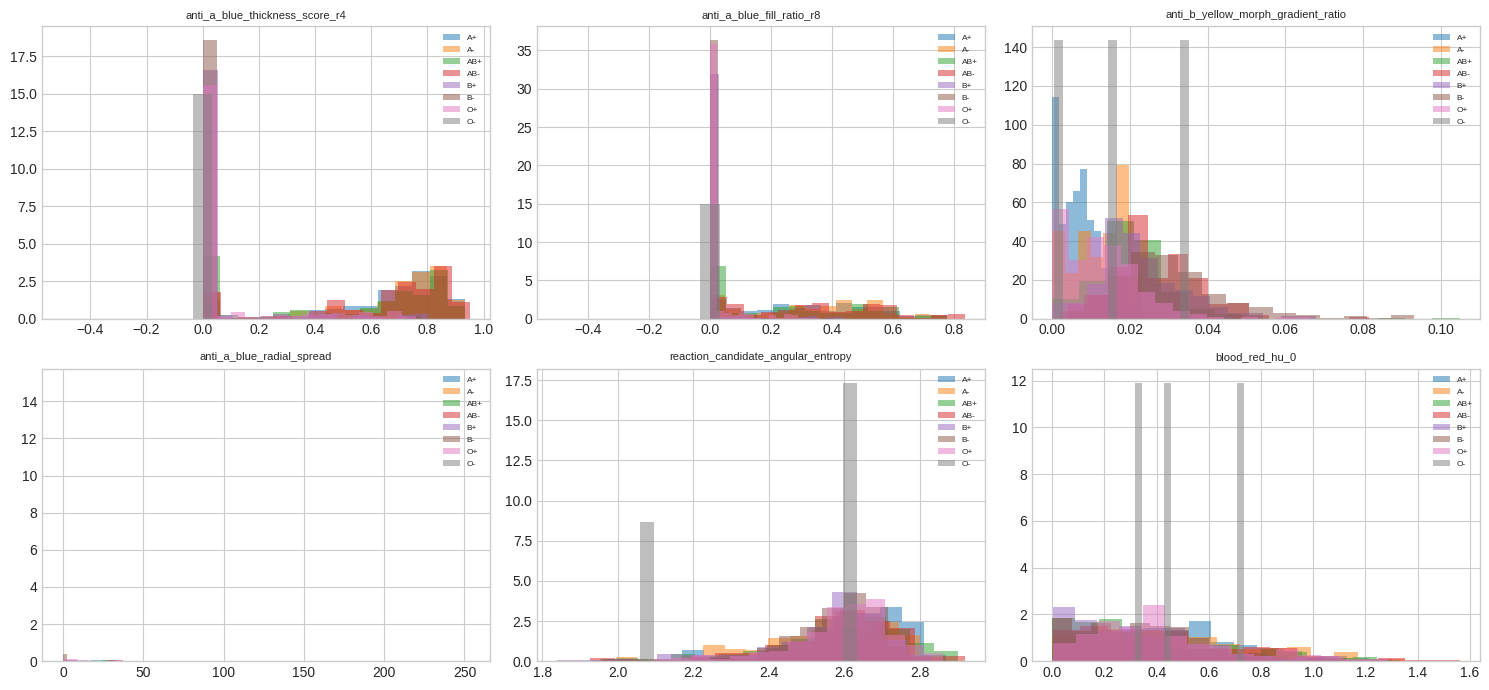

In [10]:
INSPECT = [
    "anti_a_blue_thickness_score_r4",
    "anti_a_blue_fill_ratio_r8",
    "anti_b_yellow_morph_gradient_ratio",
    "anti_a_blue_radial_spread",
    "reaction_candidate_angular_entropy",
    "blood_red_hu_0",
]
available = [f for f in INSPECT if f in morph_df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flatten(), available):
    for grp, gdf in morph_df.groupby("blood_group"):
        ax.hist(gdf[feat].dropna(), bins=15, alpha=0.5, label=grp, density=True)
    ax.set_title(feat, fontsize=8); ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/"morphological_feature_distributions.png"), dpi=100, bbox_inches="tight")
plt.show()

## 8. Ghi chú

**Morphological Profile**: 5 metrics × 4 radii + 2 extras × 5 masks = ~110 features
**Spatial Distribution**: 7 Hu + 2 centroid + 10 radial + 8 angular + 4 bbox = ~31 per mask × 5 = ~155 features

Tổng ~265 features/ảnh.

**Ưu điểm so với notebook 02**:
- Hu Moments bất biến hình học → không bị ảnh hưởng bởi góc chụp và tỷ lệ.
- Phân bố bán kính phân biệt blob đặc (peak ở bin gần tâm) vs blob viền (peak ở bin xa).
- Morphological profile đo "độ dày" ngưng kết không thể nắm bằng contour đơn thuần.

File có thể merge với `color_segmentation_features.csv` và `frequency_domain_features.csv`.
